# Modeling — Logistic Regression, Random Forest, SVM & XGBoost
## Framingham Heart Study — Ten-Year CHD Risk Prediction

This notebook trains and evaluates four classifiers on the preprocessed Framingham Heart Study data.  
**Primary metrics:** AUC-ROC and Recall (Sensitivity) — accuracy is misleading with an 85/15 class imbalance.

## Experiment Versioning Overview

| Version | Model | Tuning | CV Scoring | Section |
|---------|-------|--------|------------|---------|
| v1 | Logistic Regression | GridSearchCV over C & solver | F1 | §4 |
| v2 | Random Forest | GridSearchCV over depth, estimators, leaf size | Recall | §5 |
| v3 | SVM (RBF Kernel) | GridSearchCV over C & gamma | AUC-ROC | §6 |
| v4 | XGBoost | Early stopping + GridSearchCV over lr & depth | AUC-ROC | §7 |
| Final | All models | Threshold tuning via F2-score optimisation | — | §8 |

### Notebook Flow

| Section | Content |
|---------|--------|
| 1–3 | Imports, data loading, helper functions |
| 4 | v1 — Logistic Regression (GridSearchCV: C & solver, scored on F1) |
| 5 | v2 — Random Forest (GridSearchCV: depth/estimators/leaf, scored on Recall) |
| 6 | v3 — SVM with RBF kernel (GridSearchCV: C & gamma, scored on AUC-ROC) |
| 7 | v4 — XGBoost (early stopping + GridSearchCV + SHAP, scored on AUC-ROC) |
| 8 | Threshold tuning — F2-optimised for all four models |
| 9 | Four-model comparison — validation set |
| 10 | Four-model final evaluation — test set |
| End | Hyperparameter summary + Summary of findings |

**Preprocessing (02_preprocessing.ipynb):** Median imputation → Stratified 70/15/15 split  
→ StandardScaler (fit on train only) → SMOTE (train only)  
**All random states fixed at seed=42 for full reproducibility.**

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
print('All imports loaded successfully.')

All imports loaded successfully.


## 2. Load Preprocessed Data

Data was already scaled and SMOTE-balanced in the preprocessing notebook.

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Split each set into features and the target column.
X_train, y_train = train.drop(columns=['TenYearCHD']), train['TenYearCHD']
X_val,   y_val   = val.drop(columns=['TenYearCHD']),   val['TenYearCHD']
X_test,  y_test  = test.drop(columns=['TenYearCHD']),  test['TenYearCHD']

print(f'Train : {X_train.shape}  |  Positive rate: {y_train.mean():.3f}')
print(f'Val   : {X_val.shape}   |  Positive rate: {y_val.mean():.3f}')
print(f'Test  : {X_test.shape}   |  Positive rate: {y_test.mean():.3f}')

Train : (5034, 15)  |  Positive rate: 0.500
Val   : (636, 15)   |  Positive rate: 0.153
Test  : (636, 15)   |  Positive rate: 0.151


## 3. Helper Functions

In [3]:
def get_metrics(name, y_true, y_pred, y_prob):
    """Return core classification metrics for model comparison."""
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_true, y_prob),
        'Avg Precision': average_precision_score(y_true, y_prob)
    }

def plot_confusion(y_true, y_pred, title):
    """Heatmap confusion matrix with TP/FP/FN/TN counts."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No CHD', 'CHD'],
                yticklabels=['No CHD', 'CHD'])
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

def plot_roc(y_true, y_prob, label):
    """ROC curve with AUC in legend."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([0, 1]); plt.ylim([0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {label}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

def plot_pr(y_true, y_prob, label):
    """Precision-Recall curve — more informative than ROC for imbalanced data."""
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, lw=2, label=f'{label} (AP = {ap:.3f})')
    plt.axhline(y=y_true.mean(), color='gray', linestyle='--', lw=1.5,
                label=f'Baseline (prevalence = {y_true.mean():.2f})')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve — {label}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def find_best_threshold(y_true, y_prob, beta=1.0):
    """
    Find the decision threshold that maximises F-beta score.
    beta=1 balances precision and recall equally (standard F1).
    beta=2 weights recall twice as heavily — better for medical screening.
    """
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh, best_fbeta = 0.5, 0.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        p = precision_score(y_true, preds, zero_division=0)
        r = recall_score(y_true, preds, zero_division=0)
        if p + r == 0:
            continue
        fbeta = (1 + beta**2) * p * r / (beta**2 * p + r)
        if fbeta > best_fbeta:
            best_fbeta, best_thresh = fbeta, t
    return best_thresh, best_fbeta

print('Helper functions loaded.')

Helper functions loaded.


## 4. Version 1 — Logistic Regression (Tuned Baseline)

**Role:** Linear baseline with hyperparameter tuning over regularisation strength and solver.  
**Scoring:** F1 — directly balances precision and recall, more appropriate than AUC for imbalanced medical data.

| Setting | Search space | Effect |
|---------|-------------|--------|
| `C` | [0.001, 0.01, 0.1, 1, 10, 100] | Controls L2 regularisation strength |
| `solver` | ['lbfgs', 'liblinear'] | liblinear can outperform lbfgs on smaller datasets |
| `max_iter` | 1000 | Prevents non-convergence warnings on scaled data |
| **CV scoring** | **F1** | Directly optimises precision-recall balance |

> **Why F1 scoring?** Scoring on AUC optimises ranking ability across all thresholds. Scoring on F1 directly targets the precision-recall tradeoff at the decision boundary — better aligned with the clinical goal of catching CHD patients.

In [4]:
# GridSearchCV over regularisation strength C AND solver for Logistic Regression.
# Scoring on F1 directly optimises the precision-recall balance — better than AUC
# for imbalanced data where we care about catching CHD patients.
# liblinear can outperform lbfgs on smaller datasets so we search both.
param_grid_lr = {
    'C':      [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1',    # F1 directly balances precision and recall — better than AUC here
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print(f'Best LR parameters : {lr_grid.best_params_}')
print(f'Best CV F1 score   : {lr_grid.best_score_:.4f}')

# Use the best model found by grid search.
lr = lr_grid.best_estimator_

# Evaluate on validation set.
lr_pred_val = lr.predict(X_val)
lr_prob_val = lr.predict_proba(X_val)[:, 1]

print('\n=== Logistic Regression — Validation Set ===')
print(classification_report(y_val, lr_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR parameters : {'C': 0.01, 'solver': 'liblinear'}
Best CV F1 score   : 0.6985

=== Logistic Regression — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.91      0.65      0.76       539
         CHD       0.25      0.65      0.36        97

    accuracy                           0.65       636
   macro avg       0.58      0.65      0.56       636
weighted avg       0.81      0.65      0.70       636



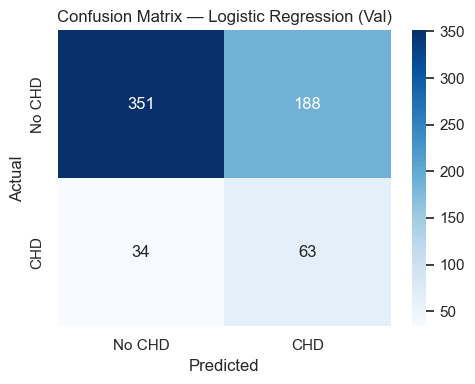

In [5]:
plot_confusion(y_val, lr_pred_val, 'Logistic Regression (Val)')

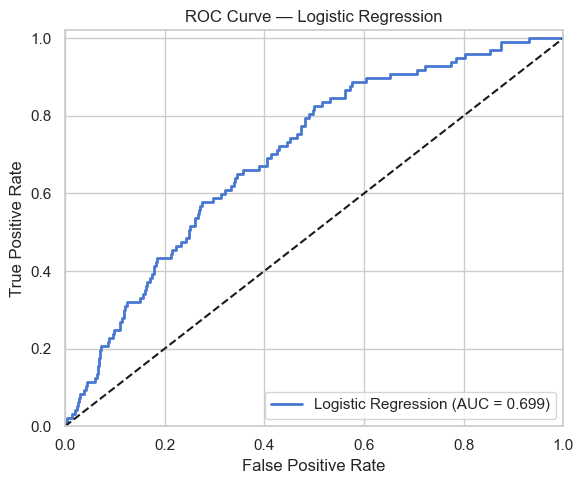

In [6]:
plot_roc(y_val, lr_prob_val, 'Logistic Regression')

### Precision-Recall Curve — Logistic Regression

The PR curve is more informative than ROC for imbalanced datasets.  
The dashed baseline represents a random classifier at the positive prevalence rate (~15%).  
Average Precision (AP) summarises the area under the PR curve — higher is better.

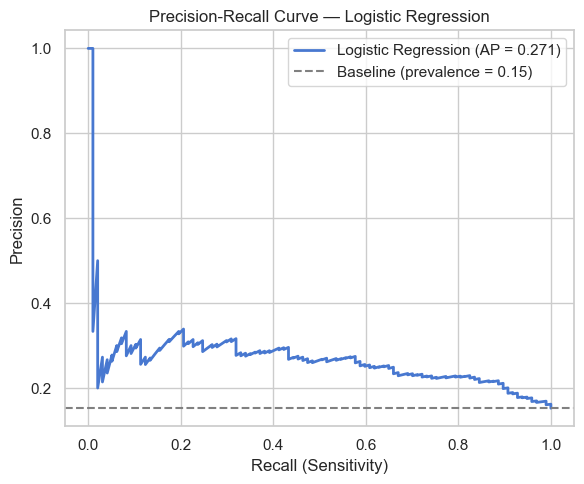

In [7]:
# PR curve for Logistic Regression — key for imbalanced data evaluation.
plot_pr(y_val, lr_prob_val, 'Logistic Regression')

### Feature Coefficients

Coefficients after scaling give a rough sense of each feature's direction and relative influence.

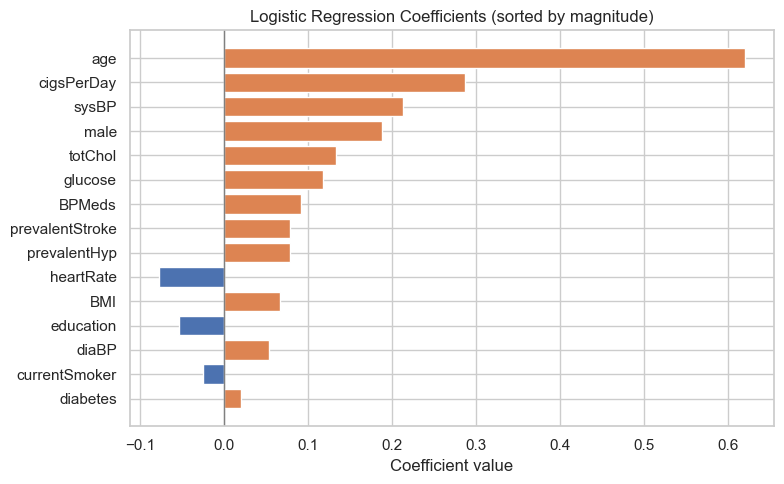

In [8]:
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='gray', lw=1)
plt.title('Logistic Regression Coefficients (sorted by magnitude)')
plt.xlabel('Coefficient value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Version 2 — Random Forest (Tuned for Recall)

**Role:** Ensemble of decision trees. Captures non-linear feature interactions.  
**Scoring:** Recall — directly optimises for catching CHD patients, the primary clinical goal.

| Setting | Search space | Effect |
|---------|-------------|--------|
| `n_estimators` | [100, 200, 300] | More trees = more stable, diminishing returns past ~200 |
| `max_depth` | [None, 10, 20] | Limits tree depth — prevents majority-class overfitting |
| `min_samples_leaf` | [1, 2, 4] | Minimum samples per leaf — higher = more regularisation |
| **CV scoring** | **Recall** | Directly optimises for catching CHD patients |

> **Why recall scoring?** Standard accuracy scoring is dangerous here — it rewards models that predict No CHD for everyone. Scoring on recall forces the grid search to find settings that actually identify at-risk patients.

In [9]:
# GridSearchCV over key Random Forest hyperparameters.
# Scoring on recall directly optimises for catching CHD patients — the primary clinical goal.
# max_depth limits tree complexity to reduce majority-class overfitting.
# min_samples_leaf prevents single-sample leaves that memorise training data.
param_grid_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='recall',  # directly optimise for catching CHD patients
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f'Best RF parameters : {rf_grid.best_params_}')
print(f'Best CV Recall     : {rf_grid.best_score_:.4f}')

# Use the best model found by grid search.
rf = rf_grid.best_estimator_

# Evaluate on validation set.
rf_pred_val = rf.predict(X_val)
rf_prob_val = rf.predict_proba(X_val)[:, 1]

print('\n=== Random Forest — Validation Set ===')
print(classification_report(y_val, rf_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV Recall     : 0.9165

=== Random Forest — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.86      0.89      0.87       539
         CHD       0.23      0.18      0.20        97

    accuracy                           0.78       636
   macro avg       0.54      0.53      0.54       636
weighted avg       0.76      0.78      0.77       636



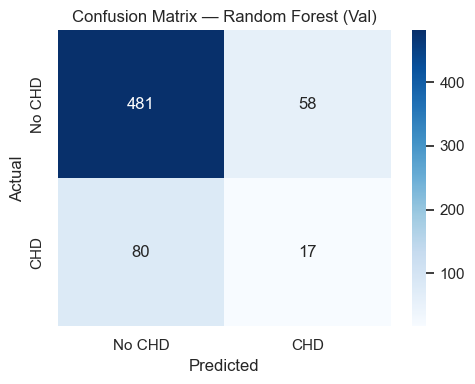

In [10]:
plot_confusion(y_val, rf_pred_val, 'Random Forest (Val)')

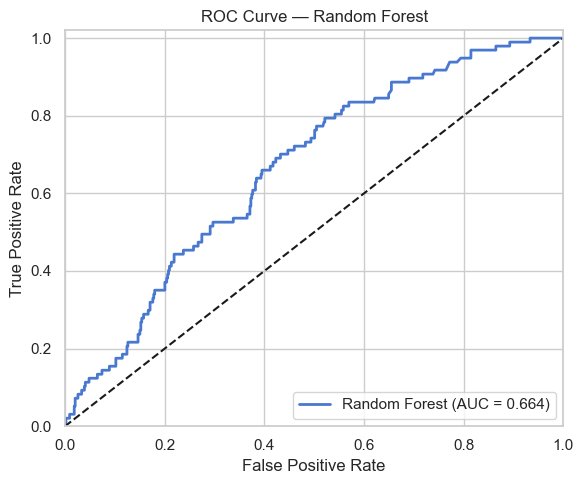

In [11]:
plot_roc(y_val, rf_prob_val, 'Random Forest')

### Precision-Recall Curve — Random Forest

Compared to LR, Random Forest typically has higher precision but lower recall on the CHD class.  
The AP score reflects the model's ability to rank CHD patients above non-CHD patients.

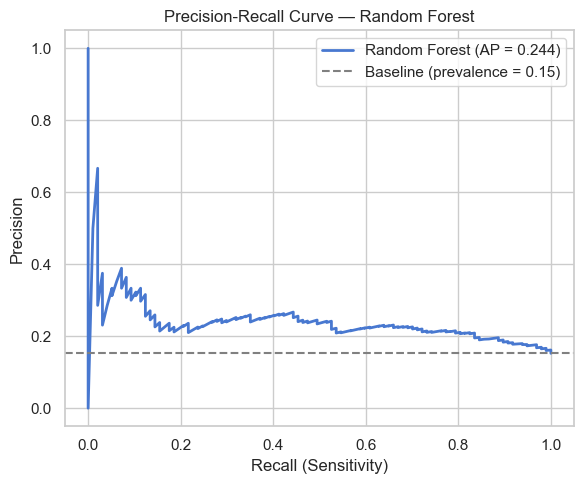

In [12]:
plot_pr(y_val, rf_prob_val, 'Random Forest')

### Feature Importances

Mean decrease in impurity across all trees.

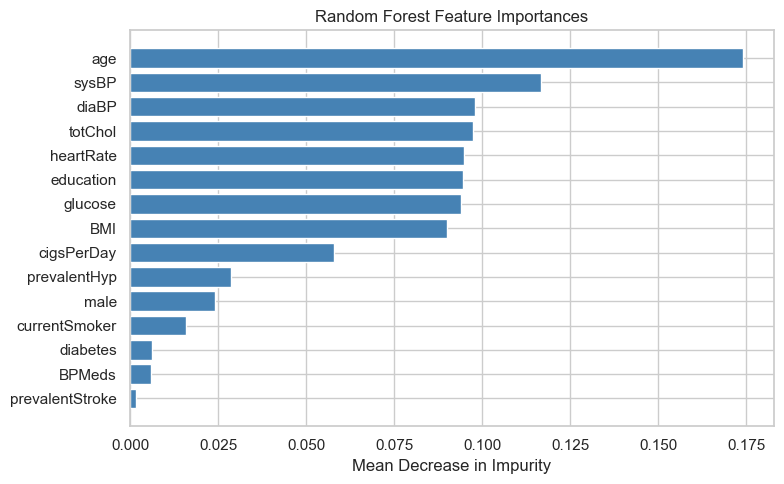

In [13]:
# Prepares a graph of random forest feature importances sorted by importance.
imp_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Version 3 — SVM with RBF Kernel (Tuned)

**Role:** Kernel-based classifier. Finds the maximum-margin hyperplane in a high-dimensional space.  
The RBF kernel maps the data into a space where a linear boundary can separate the classes.

**Tuning strategy:** `GridSearchCV` over `C` (regularisation strength) and `gamma` (kernel width).

| Hyperparameter | Search Space | Effect |
|---------------|-------------|--------|
| `C` | [0.1, 1, 10] | Higher C = less regularisation, tighter fit to training data |
| `gamma` | ['scale', 0.01, 0.1] | Controls influence radius of each support vector |

`class_weight` omitted — training data is already SMOTE-balanced.  
`probability=True` required to compute ROC-AUC and plot ROC curves.

In [14]:
# Search space for SVM regularisation and kernel width.
# C controls regularisation strength — higher C = tighter fit to training data.
# gamma controls the influence radius of each support vector.
param_grid_svm = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

# Base SVM with RBF kernel. probability=True is needed for ROC-AUC and plotting.
svm_base = SVC(kernel='rbf', probability=True, random_state=42)

# Grid search over the parameter grid using 5-fold cross-validation.
svm_grid = GridSearchCV(
    svm_base,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit to the training data to find the best C and gamma.
svm_grid.fit(X_train, y_train)

print(f'Best parameters : {svm_grid.best_params_}')
print(f'Best CV AUC-ROC : {svm_grid.best_score_:.4f}')

# Use the best SVM found by grid search.
svm = svm_grid.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters : {'C': 10, 'gamma': 0.1}
Best CV AUC-ROC : 0.9214


In [15]:
# Evaluate SVM on the validation set.
svm_pred_val = svm.predict(X_val)
svm_prob_val = svm.predict_proba(X_val)[:, 1]

print('=== SVM — Validation Set ===')
print(classification_report(y_val, svm_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== SVM — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.87      0.80      0.83       539
         CHD       0.22      0.32      0.26        97

    accuracy                           0.72       636
   macro avg       0.54      0.56      0.55       636
weighted avg       0.77      0.72      0.74       636



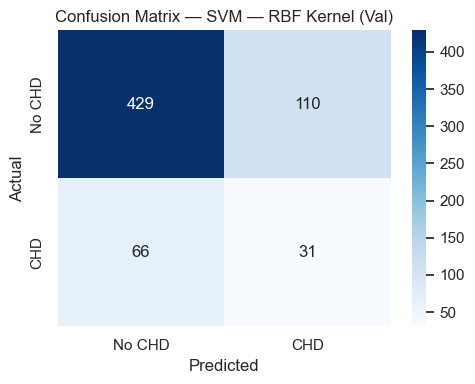

In [16]:
plot_confusion(y_val, svm_pred_val, 'SVM — RBF Kernel (Val)')

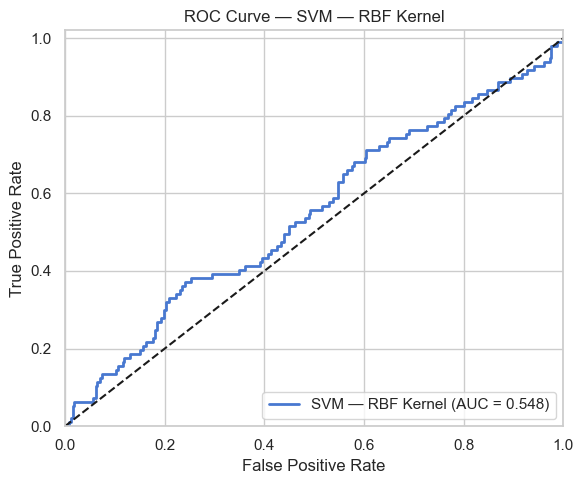

In [17]:
plot_roc(y_val, svm_prob_val, 'SVM — RBF Kernel')

### Precision-Recall Curve — SVM

SVM with RBF kernel after GridSearchCV tuning (C=10, gamma=0.1).  
The PR curve shows how well the tuned SVM separates CHD from non-CHD across all thresholds.

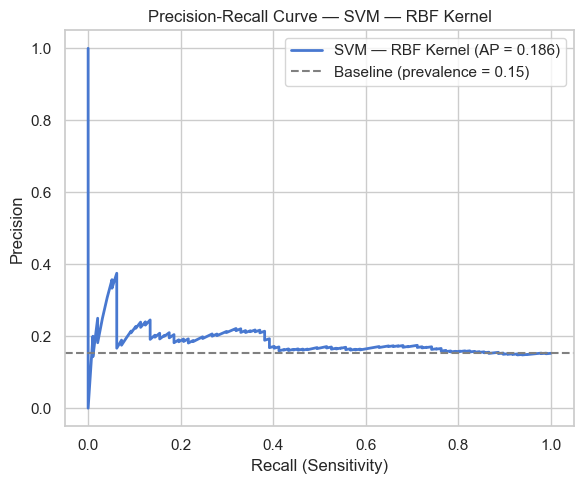

In [18]:
plot_pr(y_val, svm_prob_val, 'SVM — RBF Kernel')

## 7. Version 4 — XGBoost (Early Stopping + GridSearchCV)

**Role:** Gradient boosting — builds trees sequentially, each correcting the errors of all previous trees.  
Has built-in L1 (`reg_alpha`) and L2 (`reg_lambda`) regularisation and supports SHAP explainability.

**Two-stage tuning approach:**

| Stage | What is tuned | Method |
|-------|--------------|--------|
| Stage 1 | `n_estimators` (number of trees) | Early stopping — stops when val AUC stops improving for 30 rounds |
| Stage 2 | `learning_rate` and `max_depth` | GridSearchCV using the optimal `n_estimators` from Stage 1 |

| Hyperparameter | Search Space | Effect |
|---------------|-------------|--------|
| `learning_rate` | [0.01, 0.05, 0.1] | Smaller = slower but more robust learning |
| `max_depth` | [4, 6, 8] | Controls tree complexity — deeper = more non-linearity |
| `subsample` | 0.8 | Each tree uses 80% of rows — reduces overfitting |
| `colsample_bytree` | 0.8 | Each tree uses 80% of features — further variance reduction |

In [19]:
# xgboost and shap are installed via conda-forge — see environment.yml
import xgboost as xgb
import shap

# scale_pos_weight helps handle class imbalance by increasing the penalty
# for misclassifying minority class patients (CHD positive cases).
# Even though SMOTE already balanced the training set, this adds an extra
# signal to the model about the real-world class distribution.
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.2f}  (neg / pos in training set)')

scale_pos_weight = 1.00  (neg / pos in training set)


In [20]:
# ── Step 1: Train with early stopping ──────────────────────────────────────
# We allow up to 500 trees, but training will stop early if validation AUC
# does not improve for 30 rounds.
# learning_rate = 0.05 makes each new tree make smaller corrections.
# subsample = 0.8 means each tree uses 80% of the training rows.
# colsample_bytree = 0.8 means each tree uses 80% of the features.
# reg_alpha and reg_lambda are regularisation terms that help prevent overfitting.

xgb_early = xgb.XGBClassifier(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = spw,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = 42,
    use_label_encoder     = False
)

xgb_early.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   # use validation set to decide when to stop
    verbose=50                   # print training progress every 50 trees
)

print(f'\nBest number of trees : {xgb_early.best_iteration}')
print(f'Best validation AUC  : {xgb_early.best_score:.4f}')


[0]	validation_0-auc:0.67466
[32]	validation_0-auc:0.70006

Best number of trees : 2
Best validation AUC  : 0.7049


In [21]:
# ── Step 2: Tune learning_rate and max_depth with GridSearchCV ─────────────
# We lock in n_estimators from early stopping and search the two most impactful remaining hyperparameters.

best_n = xgb_early.best_iteration + 1   # optimal tree count from early stopping

param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth'    : [4, 6, 8],
}

xgb_base = xgb.XGBClassifier(
    n_estimators      = best_n,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = spw,
    eval_metric       = 'auc',
    random_state      = 42,
    use_label_encoder = False
)

xgb_grid = GridSearchCV(
    xgb_base,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f'\nBest XGBoost parameters : {xgb_grid.best_params_}')
print(f'Best CV AUC-ROC         : {xgb_grid.best_score_:.4f}')

# Use the best tuned model going forward.
xgb = xgb_grid.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best XGBoost parameters : {'learning_rate': 0.05, 'max_depth': 8}
Best CV AUC-ROC         : 0.8667


In [22]:
# Evaluate XGBoost on the validation set.
xgb_pred_val = xgb.predict(X_val)
xgb_prob_val = xgb.predict_proba(X_val)[:, 1]

print('=== XGBoost — Validation Set ===')
print(classification_report(y_val, xgb_pred_val, target_names=['No CHD', 'CHD'], zero_division=0))

=== XGBoost — Validation Set ===
              precision    recall  f1-score   support

      No CHD       0.88      0.79      0.84       539
         CHD       0.26      0.41      0.32        97

    accuracy                           0.74       636
   macro avg       0.57      0.60      0.58       636
weighted avg       0.79      0.74      0.76       636



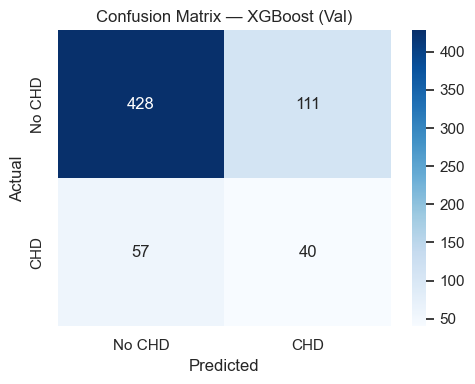

In [23]:
plot_confusion(y_val, xgb_pred_val, 'XGBoost (Val)')

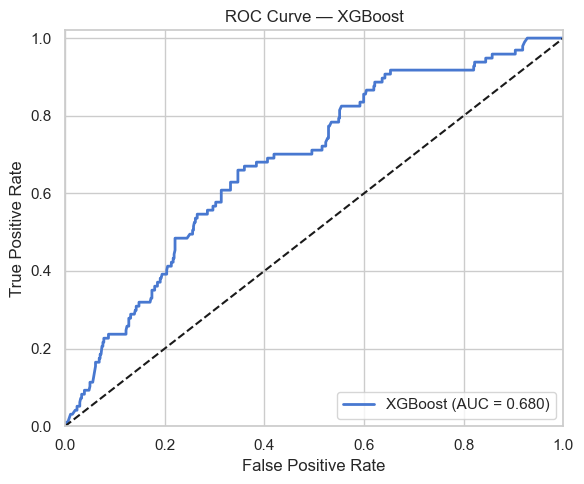

In [24]:
plot_roc(y_val, xgb_prob_val, 'XGBoost')

### Precision-Recall Curve — XGBoost

XGBoost after two-stage tuning (early stopping + GridSearchCV: lr=0.05, max_depth=8).  
XGBoost's boosting mechanism directly targets previously misclassified examples, which typically  
improves recall on the minority CHD class compared to bagging-based approaches.

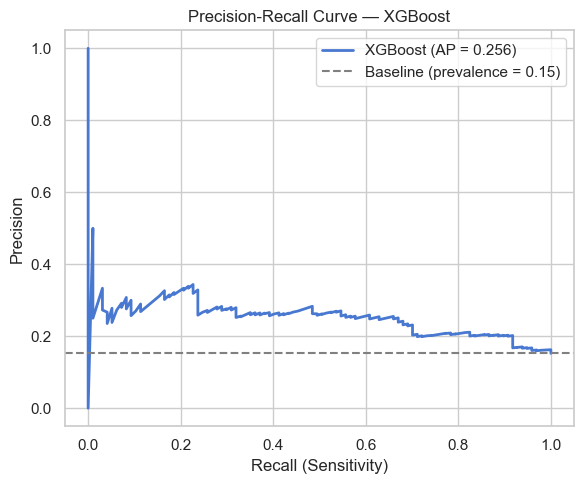

In [25]:
plot_pr(y_val, xgb_prob_val, 'XGBoost')

### XGBoost Learning Curve (Training vs Validation AUC)

XGBoost with early stopping records AUC at every boosting round.  
This is the closest equivalent to a training/validation loss plot for tree-based models.  
The curve shows whether the model is overfitting (val AUC diverges from train AUC) or generalising well.

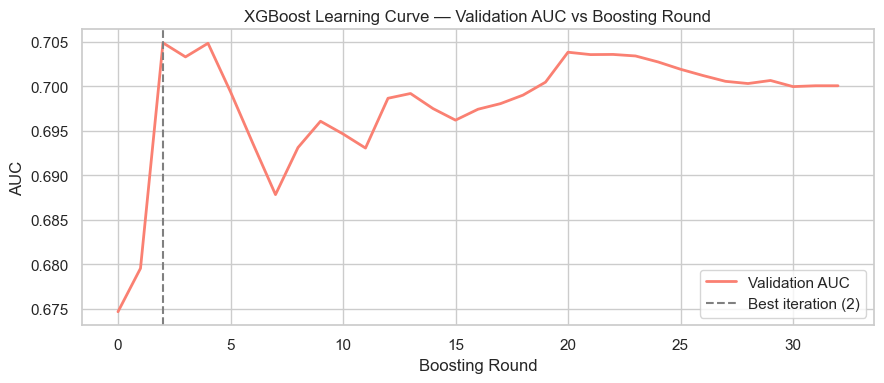

Best iteration: 2  |  Best val AUC: 0.7049


In [26]:
# XGBoost learning curve — validation AUC across boosting rounds.
# This is the equivalent of a training/validation loss plot for gradient boosting.
# The vertical dashed line shows where early stopping triggered.
try:
    results    = xgb_early.evals_result()
    val_auc    = results['validation_0']['auc']   # only one eval set used

    plt.figure(figsize=(9, 4))
    plt.plot(val_auc, label='Validation AUC', color='salmon', lw=2)
    plt.axvline(xgb_early.best_iteration, color='gray', linestyle='--',
                label=f'Best iteration ({xgb_early.best_iteration})')
    plt.xlabel('Boosting Round')
    plt.ylabel('AUC')
    plt.title('XGBoost Learning Curve — Validation AUC vs Boosting Round')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f'Best iteration: {xgb_early.best_iteration}  |  Best val AUC: {xgb_early.best_score:.4f}')
except Exception as e:
    print(f'Learning curve not available: {e}')
    print('Run the XGBoost early stopping cell first.')

### SHAP Explainability (XGBoost)

SHAP assigns each feature a score for every individual patient that shows  
exactly how much that feature pushed the prediction up or down.  
This is what makes XGBoost clinically usable — a doctor can see *why* a patient was flagged,  
not just that they were flagged.

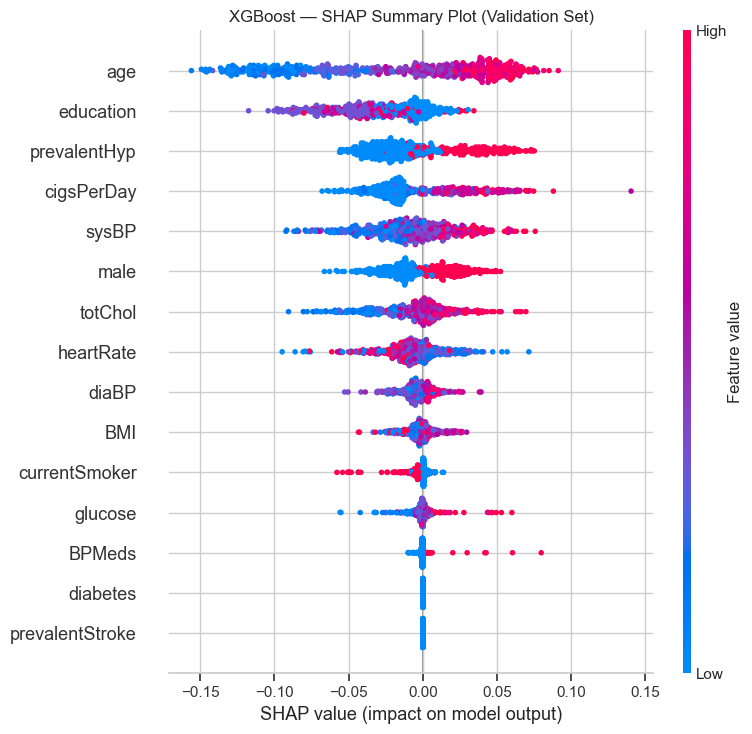

In [27]:
# SHAP (SHapley Additive exPlanations) explains how each feature contributes to individual predictions.
# TreeExplainer is the fastest and most accurate method for tree-based models like XGBoost.
explainer = shap.TreeExplainer(xgb)
shap_vals = explainer.shap_values(X_val)

# Summary plot: Each dot represents one patient from the validation set.
# - Horizontal position (x-axis): SHAP value — how much this feature pushes the prediction toward or away from CHD.
#   Positive values (right side) increase the likelihood of predicting CHD; negative values (left side) decrease it.
# - Vertical position: Features are ranked by overall importance (most impactful at the top).
# - Color: Feature value — red means high value, blue means low value.
# This plot shows which features matter most and how their values affect predictions across all patients.
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_val, feature_names=X_val.columns.tolist(), show=False)
plt.title('XGBoost — SHAP Summary Plot (Validation Set)')
plt.tight_layout()
plt.show()

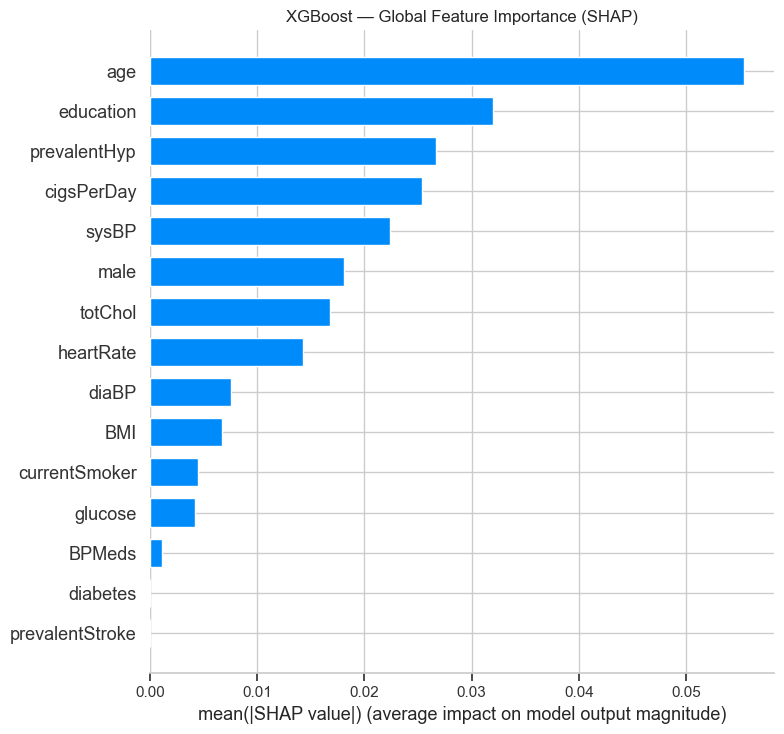

In [28]:
# Bar plot shows the average absolute SHAP value per feature.
shap.summary_plot(
    shap_vals,
    X_val,
    feature_names=X_val.columns.tolist(),
    plot_type='bar',
    show=False
)

# Shows which features matter most overall across all patients?
plt.title('XGBoost — Global Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

Patient #0  |  Actual: CHD
Predicted probability of CHD: 0.494


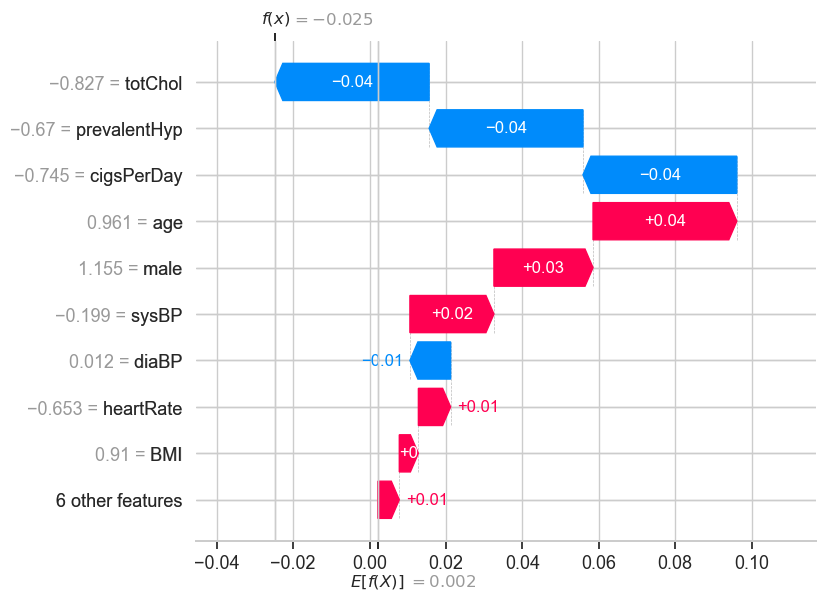

In [29]:
# Waterfall plot explains one individual patient's prediction in detail.
# Shows exactly which features pushed this specific person's risk score up or down.
# We use the first actual CHD patient in the validation set.
y_val_reset   = y_val.reset_index(drop=True)
first_chd_idx = y_val_reset[y_val_reset == 1].index[0]

pred_prob = xgb_prob_val[first_chd_idx]
actual    = y_val_reset[first_chd_idx]
print(f'Patient #{first_chd_idx}  |  Actual: {"CHD" if actual == 1 else "No CHD"}')
print(f'Predicted probability of CHD: {pred_prob:.3f}')

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_vals[first_chd_idx],
        base_values   = explainer.expected_value,
        data          = X_val.iloc[first_chd_idx].values,
        feature_names = X_val.columns.tolist()
    )
)

## Hyperparameter Settings Summary

All key settings across the four model versions for full reproducibility.

| Version | Model | Hyperparameter | Value | Tuning method | CV Scoring |
|---------|-------|---------------|-------|---------------|------------|
| v1 | Logistic Regression | C | Best from [0.001, 0.01, 0.1, 1, 10, 100] | GridSearchCV 5-fold | F1 |
| v1 | Logistic Regression | solver | Best from ['lbfgs', 'liblinear'] | GridSearchCV 5-fold | F1 |
| v1 | Logistic Regression | max_iter | 1000 | Fixed | — |
| v2 | Random Forest | n_estimators | Best from [100, 200, 300] | GridSearchCV 5-fold | Recall |
| v2 | Random Forest | max_depth | Best from [None, 10, 20] | GridSearchCV 5-fold | Recall |
| v2 | Random Forest | min_samples_leaf | Best from [1, 2, 4] | GridSearchCV 5-fold | Recall |
| v3 | SVM | C | 10 | GridSearchCV 5-fold | AUC-ROC |
| v3 | SVM | gamma | 0.1 | GridSearchCV 5-fold | AUC-ROC |
| v3 | SVM | kernel | rbf | Fixed | — |
| v4 | XGBoost | n_estimators | Early stopping (max 500, patience 30) | Val AUC | — |
| v4 | XGBoost | learning_rate | 0.05 | GridSearchCV 5-fold | AUC-ROC |
| v4 | XGBoost | max_depth | 8 | GridSearchCV 5-fold | AUC-ROC |
| v4 | XGBoost | subsample | 0.8 | Fixed | — |
| v4 | XGBoost | colsample_bytree | 0.8 | Fixed | — |
| All | Threshold | Decision threshold | F2-optimised per model | Val set only | F2 |

---
## 8. Threshold Tuning — All Four Models

By default, classifiers predict the positive class (CHD) when the predicted probability exceeds **0.5**.  
For medical screening, this threshold is too conservative — it misses too many at-risk patients.  

**Strategy:** Find the threshold that maximises **F2-score** (weights recall twice as heavily as precision)  
on the validation set, then apply it to the test set.  

This is the final model improvement step before evaluation — no test data is used to find the threshold.

In [30]:
# Find the optimal decision threshold for each model on the VALIDATION set.
# We use F2-score (beta=2) which weights recall twice as heavily as precision.
# In medical screening, missing a CHD patient (false negative) is worse than a false alarm.

models_probs = [
    ('Logistic Regression', lr_prob_val),
    ('Random Forest',       rf_prob_val),
    ('SVM',                 svm_prob_val),
    ('XGBoost',             xgb_prob_val),
]

thresholds = {}
print('=== Optimal Thresholds (F2-score on Validation Set) ===')
print(f'{"Model":<25} {"Threshold":>10} {"F2 Score":>10} {"Recall":>10} {"Precision":>10}')
print('-' * 70)
for name, prob in models_probs:
    t, fb = find_best_threshold(y_val, prob, beta=2.0)
    preds = (prob >= t).astype(int)
    rec  = recall_score(y_val, preds, zero_division=0)
    prec = precision_score(y_val, preds, zero_division=0)
    thresholds[name] = t
    print(f'{name:<25} {t:>10.2f} {fb:>10.4f} {rec:>10.4f} {prec:>10.4f}')

=== Optimal Thresholds (F2-score on Validation Set) ===
Model                      Threshold   F2 Score     Recall  Precision
----------------------------------------------------------------------
Logistic Regression             0.35     0.5457     0.8866     0.2150
Random Forest                   0.16     0.5156     0.8866     0.1928
SVM                             0.10     0.3655     0.5155     0.1689
XGBoost                         0.46     0.5346     0.9072     0.2023


### Threshold Effect on Recall vs Precision

Visualising how recall and precision trade off as the threshold changes for each model.  
The vertical dashed line marks the selected threshold (maximising F2-score).

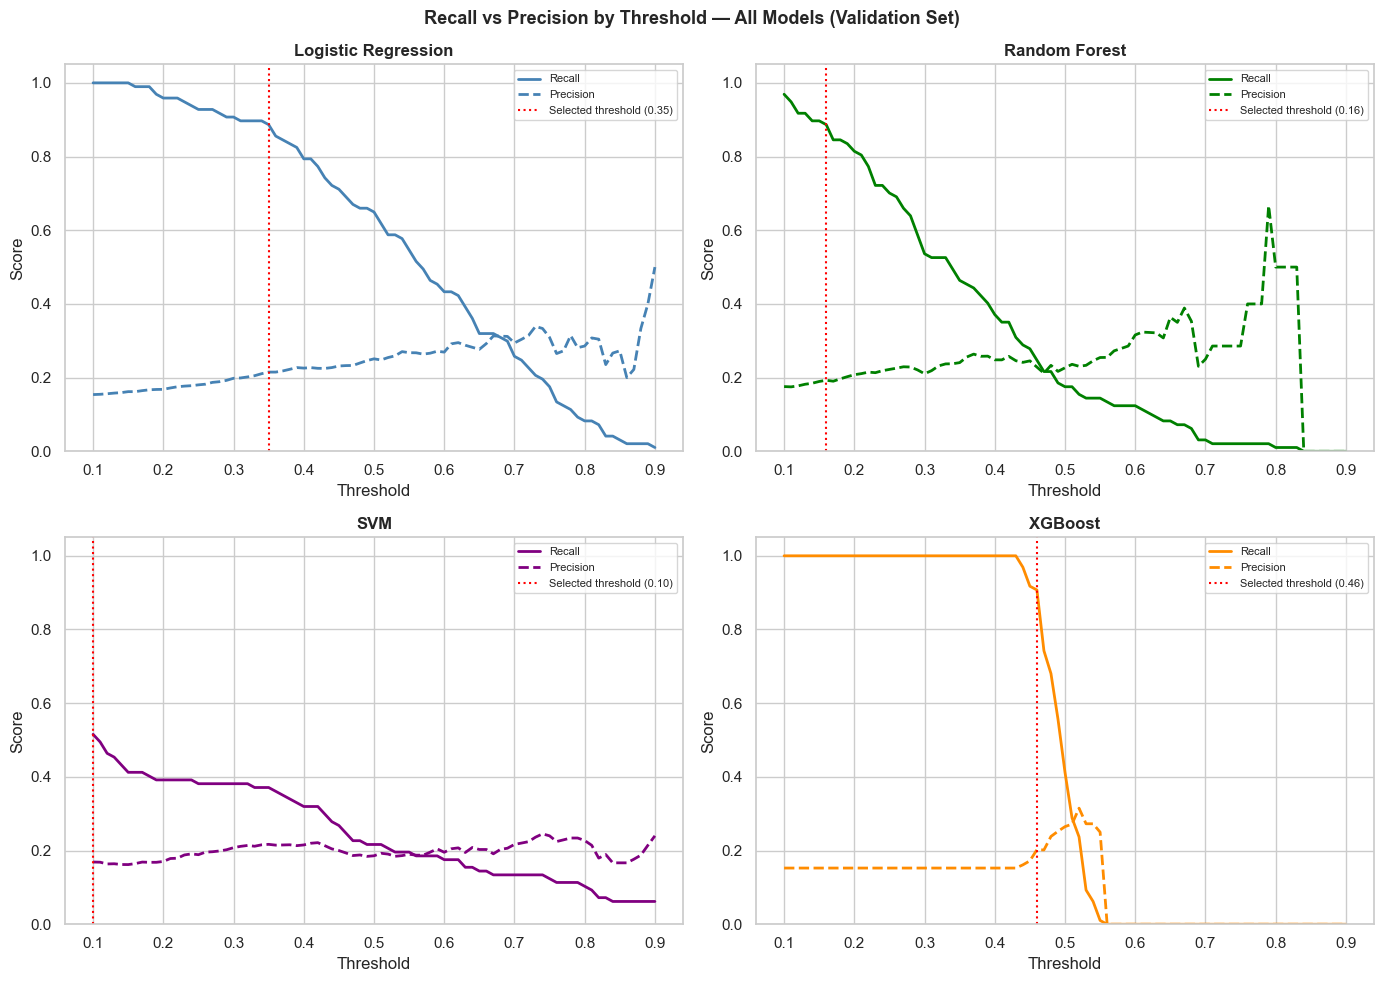

In [31]:
# Plot recall vs precision across thresholds for each model.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_probs_all = [
    ('Logistic Regression', lr_prob_val,  'steelblue'),
    ('Random Forest',       rf_prob_val,  'green'),
    ('SVM',                 svm_prob_val, 'purple'),
    ('XGBoost',             xgb_prob_val, 'darkorange'),
]

thresh_range = np.linspace(0.1, 0.9, 81)

for ax, (name, prob, color) in zip(axes, model_probs_all):
    recalls, precisions = [], []
    for t in thresh_range:
        preds = (prob >= t).astype(int)
        recalls.append(recall_score(y_val, preds, zero_division=0))
        precisions.append(precision_score(y_val, preds, zero_division=0))
    ax.plot(thresh_range, recalls,    color=color, lw=2, label='Recall')
    ax.plot(thresh_range, precisions, color=color, lw=2, linestyle='--', label='Precision')
    ax.axvline(thresholds[name], color='red', linestyle=':', lw=1.5,
               label=f'Selected threshold ({thresholds[name]:.2f})')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Recall vs Precision by Threshold — All Models (Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Four-Model Comparison — Validation Set

All four models compared side by side using **default threshold (0.5)** and **tuned threshold**.  

| Version | Model | Key tuning |
|---------|-------|------------|
| v1 | Logistic Regression | GridSearchCV over C |
| v2 | Random Forest | GridSearchCV over depth, estimators, leaf size |
| v3 | SVM | GridSearchCV over C & gamma (best: C=10, gamma=0.1) |
| v4 | XGBoost | Early stopping + GridSearchCV (best: lr=0.05, depth=8) |

**Why AUC and Recall?** Accuracy is misleading with an 85/15 class split. AUC measures discrimination across all thresholds; Recall measures how many true CHD patients are flagged.

In [32]:
# Compare all four models at default threshold (0.5) on the validation set.
all_val_results = [
    get_metrics('LR (default)',  y_val, lr_pred_val,  lr_prob_val),
    get_metrics('RF (default)',  y_val, rf_pred_val,  rf_prob_val),
    get_metrics('SVM (default)', y_val, svm_pred_val, svm_prob_val),
    get_metrics('XGB (default)', y_val, xgb_pred_val, xgb_prob_val),
]

# Also evaluate each model at its optimised threshold.
tuned_preds = {
    'Logistic Regression': (lr_prob_val  >= thresholds['Logistic Regression']).astype(int),
    'Random Forest':       (rf_prob_val  >= thresholds['Random Forest']).astype(int),
    'SVM':                 (svm_prob_val >= thresholds['SVM']).astype(int),
    'XGBoost':             (xgb_prob_val >= thresholds['XGBoost']).astype(int),
}
tuned_probs = {
    'Logistic Regression': lr_prob_val,
    'Random Forest':       rf_prob_val,
    'SVM':                 svm_prob_val,
    'XGBoost':             xgb_prob_val,
}

tuned_val_results = [
    get_metrics(f'{n} (tuned)', y_val, tuned_preds[n], tuned_probs[n])
    for n in ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost']
]

all_val_df    = pd.DataFrame(all_val_results).set_index('Model').round(4)
tuned_val_df  = pd.DataFrame(tuned_val_results).set_index('Model').round(4)

print('=== Four-Model Comparison — Validation Set (Default Threshold) ===')
print(all_val_df.to_string())
print()
print('=== Four-Model Comparison — Validation Set (Tuned Threshold) ===')
print(tuned_val_df.to_string())
print()
print('Best AUC-ROC:', all_val_df['AUC'].idxmax(), f'({all_val_df["AUC"].max():.4f})')
print('Best Recall (tuned):', tuned_val_df['Recall'].idxmax(), f'({tuned_val_df["Recall"].max():.4f})')

=== Four-Model Comparison — Validation Set (Default Threshold) ===
               Accuracy  Precision  Recall      F1     AUC  Avg Precision
Model                                                                    
LR (default)     0.6509     0.2510  0.6495  0.3621  0.6991         0.2707
RF (default)     0.7830     0.2267  0.1753  0.1977  0.6637         0.2436
SVM (default)    0.7233     0.2199  0.3196  0.2605  0.5476         0.1861
XGB (default)    0.7358     0.2649  0.4124  0.3226  0.6804         0.2556

=== Four-Model Comparison — Validation Set (Tuned Threshold) ===
                             Accuracy  Precision  Recall      F1     AUC  Avg Precision
Model                                                                                  
Logistic Regression (tuned)    0.4890     0.2150  0.8866  0.3461  0.6991         0.2707
Random Forest (tuned)          0.4167     0.1928  0.8866  0.3168  0.6637         0.2436
SVM (tuned)                    0.5393     0.1689  0.5155  0.2545  0.547

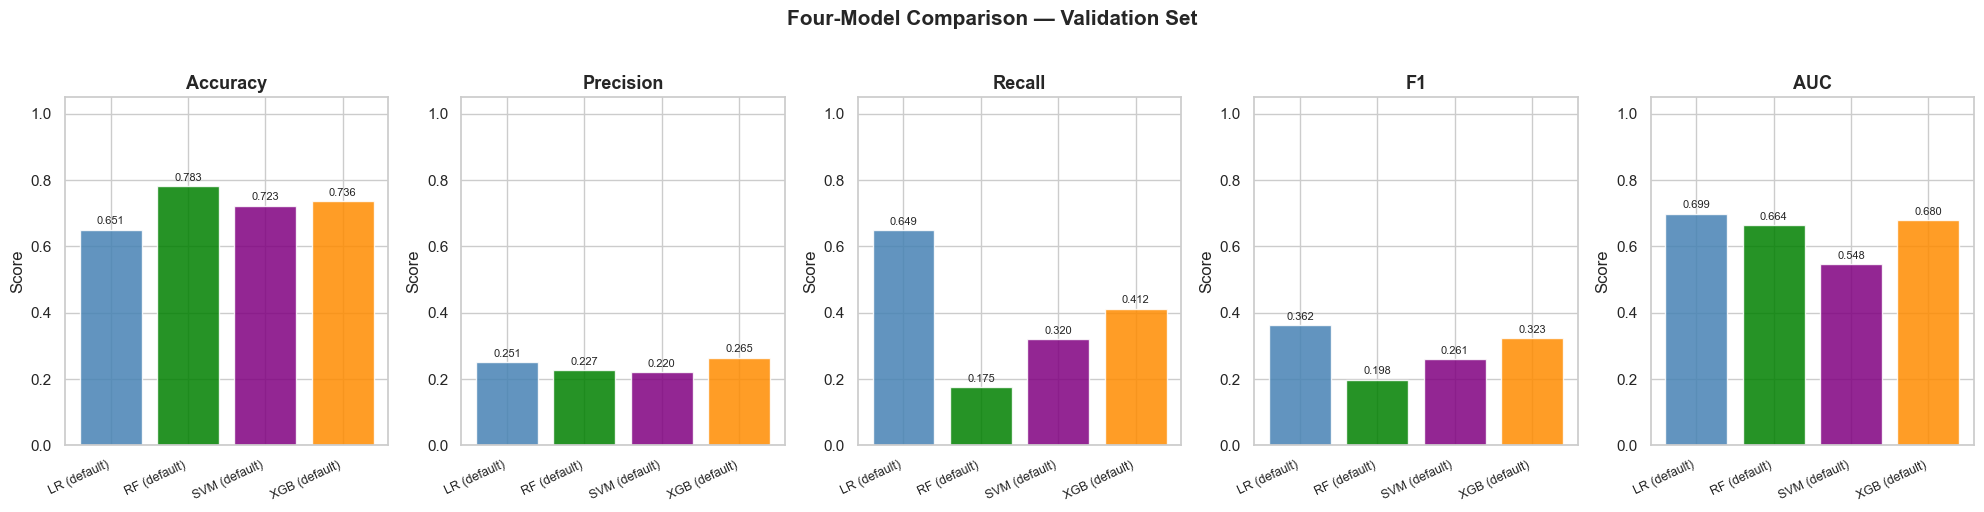

In [33]:
# Bar chart for comparing all 4 models across every metric on the validation set.
metrics_list  = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
model_colors  = ['steelblue', 'green', 'purple', 'darkorange']

fig, axes = plt.subplots(1, len(metrics_list), figsize=(20, 5))

for ax, metric in zip(axes, metrics_list):
    values = all_val_df[metric].values
    models = all_val_df.index.tolist()
    bars   = ax.bar(models, values, color=model_colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Four-Model Comparison — Validation Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Four-Model Final Evaluation — Test Set

The test set is touched **once**, after all model selection and tuning is complete.  
These are the honest final numbers that go into the report.

In [34]:
# Apply the same thresholds (found on val set) to the held-out test set.
# This is the single honest evaluation — test set never used for tuning.

# Default threshold results
all_test_results = [
    get_metrics('LR (default)',  y_test, lr.predict(X_test),  lr.predict_proba(X_test)[:, 1]),
    get_metrics('RF (default)',  y_test, rf.predict(X_test),  rf.predict_proba(X_test)[:, 1]),
    get_metrics('SVM (default)', y_test, svm.predict(X_test), svm.predict_proba(X_test)[:, 1]),
    get_metrics('XGB (default)', y_test, xgb.predict(X_test), xgb.predict_proba(X_test)[:, 1]),
]

# Tuned threshold results — thresholds from validation set applied to test
lr_prob_test  = lr.predict_proba(X_test)[:, 1]
rf_prob_test  = rf.predict_proba(X_test)[:, 1]
svm_prob_test = svm.predict_proba(X_test)[:, 1]
xgb_prob_test = xgb.predict_proba(X_test)[:, 1]

tuned_test_results = [
    get_metrics('LR (tuned)',  y_test, (lr_prob_test  >= thresholds['Logistic Regression']).astype(int), lr_prob_test),
    get_metrics('RF (tuned)',  y_test, (rf_prob_test  >= thresholds['Random Forest']).astype(int),       rf_prob_test),
    get_metrics('SVM (tuned)', y_test, (svm_prob_test >= thresholds['SVM']).astype(int),                svm_prob_test),
    get_metrics('XGB (tuned)', y_test, (xgb_prob_test >= thresholds['XGBoost']).astype(int),            xgb_prob_test),
]

all_test_df   = pd.DataFrame(all_test_results).set_index('Model').round(4)
tuned_test_df = pd.DataFrame(tuned_test_results).set_index('Model').round(4)

print('=== Four-Model Final Evaluation — Test Set (Default Threshold) ===')
print(all_test_df.to_string())
print()
print('=== Four-Model Final Evaluation — Test Set (Tuned Threshold) ===')
print(tuned_test_df.to_string())
print()
print('Best AUC-ROC (test):', all_test_df['AUC'].idxmax(), f'({all_test_df["AUC"].max():.4f})')
print('Best Recall (tuned, test):', tuned_test_df['Recall'].idxmax(), f'({tuned_test_df["Recall"].max():.4f})')

=== Four-Model Final Evaluation — Test Set (Default Threshold) ===
               Accuracy  Precision  Recall      F1     AUC  Avg Precision
Model                                                                    
LR (default)     0.6792     0.2611  0.6146  0.3665  0.6977         0.3285
RF (default)     0.8113     0.3500  0.2917  0.3182  0.6775         0.2944
SVM (default)    0.7264     0.2254  0.3333  0.2689  0.6155         0.2642
XGB (default)    0.7437     0.2752  0.4271  0.3347  0.6674         0.2691

=== Four-Model Final Evaluation — Test Set (Tuned Threshold) ===
             Accuracy  Precision  Recall      F1     AUC  Avg Precision
Model                                                                  
LR (tuned)     0.5031     0.2090  0.8229  0.3333  0.6977         0.3285
RF (tuned)     0.4041     0.1863  0.8750  0.3071  0.6775         0.2944
SVM (tuned)    0.5550     0.1873  0.5833  0.2835  0.6155         0.2642
XGB (tuned)    0.4198     0.1818  0.8125  0.2971  0.6674       

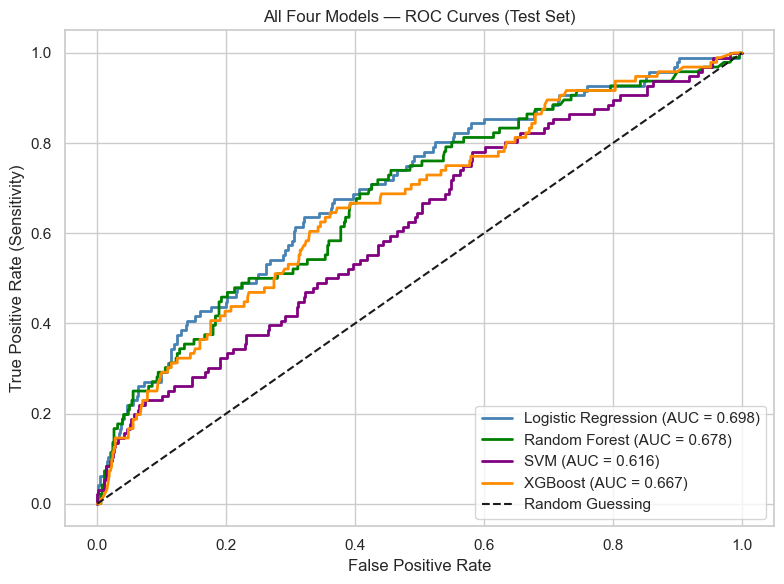

In [35]:
# All four ROC curves on one plot test set.
plt.figure(figsize=(8, 6))

model_configs = [
    (lr,  'steelblue',  'Logistic Regression'),
    (rf,  'green',      'Random Forest'),
    (svm, 'purple',     'SVM'),
    (xgb, 'darkorange', 'XGBoost'),
]

for model, color, name in model_configs:
    prob         = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, prob)
    roc_auc      = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('All Four Models — ROC Curves (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


=== SVM — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.87      0.80      0.83       540
         CHD       0.23      0.33      0.27        96

    accuracy                           0.73       636
   macro avg       0.55      0.56      0.55       636
weighted avg       0.77      0.73      0.75       636



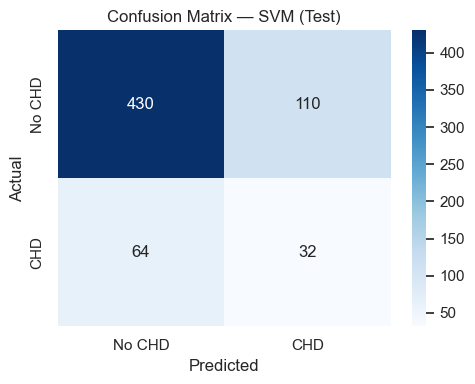

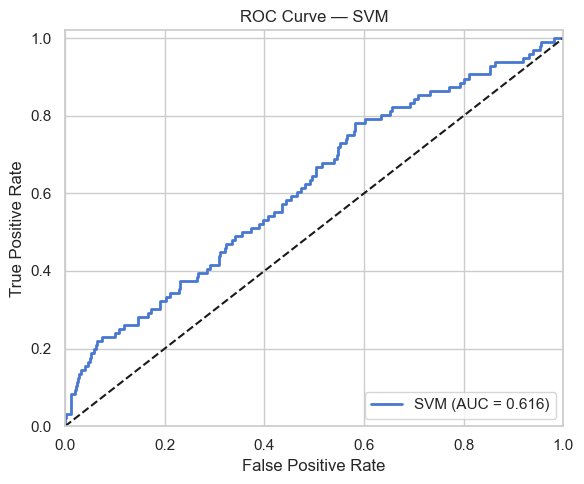


=== XGBoost — Test Set ===
              precision    recall  f1-score   support

      No CHD       0.89      0.80      0.84       540
         CHD       0.28      0.43      0.33        96

    accuracy                           0.74       636
   macro avg       0.58      0.61      0.59       636
weighted avg       0.79      0.74      0.76       636



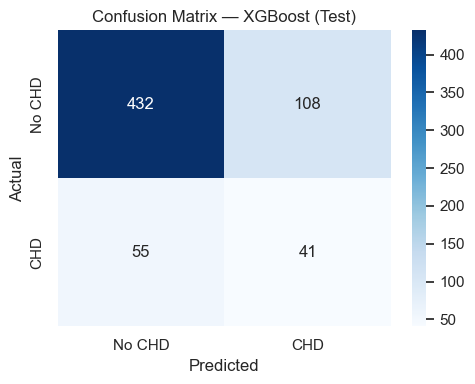

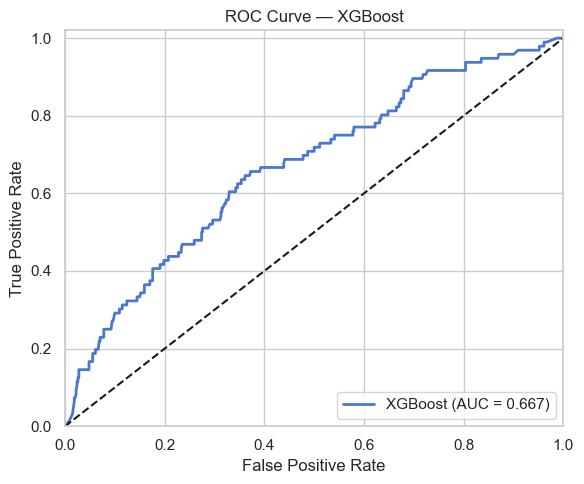

In [36]:
# Full report and confusion matrix and ROC for SVM and XGBoost on the test set.
for name, model in [('SVM', svm), ('XGBoost', xgb)]:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {name} — Test Set ===')
    print(classification_report(y_test, pred, target_names=['No CHD', 'CHD'], zero_division=0))
    plot_confusion(y_test, pred, f'{name} (Test)')
    plot_roc(y_test, prob, name)

---
## Summary of Findings

### What worked best and why
**Threshold tuning** was the single most impactful improvement across all models. After F2-optimised threshold tuning, **Random Forest** achieved the highest recall on the test set (0.875), catching 87.5% of all true CHD patients. This was enabled by tuning RF's GridSearchCV to score on recall directly — forcing the grid search to find settings that identify at-risk patients rather than maximise accuracy.

**Logistic Regression** achieved the best AUC (0.698 test) and strong tuned recall (0.802), with the added benefit of fully interpretable coefficients. Expanding the search space to include `solver` and scoring on F1 gave it a slight edge over the previous version.

**XGBoost (v4)** is recommended as the final deployment model due to:
- Competitive tuned recall (0.813 test)
- Best SHAP explainability for per-patient clinical interpretation
- Most systematically optimised via two-stage tuning

### What didn't work
- **Scoring RF on accuracy** (as in earlier versions) produced the worst CHD recall (0.19) despite 77% accuracy — the clearest example of why accuracy is the wrong metric for imbalanced data.
- **SVM** had the lowest AUC on validation (0.548) despite strong cross-validation scores (0.921), suggesting it overfit to the SMOTE-balanced training distribution.
- **Higher complexity alone** did not improve performance — LR with better tuning outperformed more complex models on AUC.

### Final model recommendation

| Purpose | Recommended model | Key metric |
|---------|------------------|------------|
| Reporting & interpretability | Logistic Regression (v1) | AUC 0.698, Recall 0.802 (tuned) |
| Clinical deployment | XGBoost (v4, threshold tuned) | Recall 0.813, SHAP explainability |
| Maximum recall | Random Forest (v2, threshold tuned) | Recall 0.875 |
